# Analysis Notebook

Load saved numpy results and generate figures (no model loading).

In [1]:

import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "results").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from metrics_utils import compute_d_arch_auc, compute_sensitivity_ratio
from viz_utils import (
    add_attention_entropy_overlay,
    add_gradcam_unreliable_overlay,
    add_logit_corr_band,
    add_resnet_gradcam_target_marker,
    load_arch_baseline_maps,
    CASCADE_DISPLAY_PRESETS,
    plot_cascade_paper_grid,
    plot_cascading_grid,
    plot_occlusion_faithfulness_curves,
    select_depth_indices,
)

RESULTS_ROOT = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CLASS_A_METHODS = ["gradient", "input_grad", "ig"]
CLASS_B_METHODS = {
    "resnet50": ["gradcam"],
    "vit": ["transformer_gradcam"],
}
CLASS_C_METHODS = {
    "resnet50": ["gbp"],
    "vit": ["raw_attn"],
}
ARCHS = {
    "resnet50": {"title": "ResNet-50"},
    "vit": {"title": "ViT-B/16"},
}
for arch in ARCHS:
    ARCHS[arch]["methods"] = (
        CLASS_A_METHODS + CLASS_B_METHODS[arch] + CLASS_C_METHODS[arch]
    )

MECH_ARCH_TAGS = [
    ("resnet", "ResNet-50"),
    ("vit", "ViT-B/16"),
]
PRIMARY_SPEARMAN = {
    "ig": "spearman_rms_mean",
    "input_grad": "spearman_rms_mean",
}
DEFAULT_PRIMARY_SPEARMAN = "spearman_abs_rms_mean"
CLASS_B_SPATIAL = {
    "resnet50": "gradcam",
    "vit": "transformer_gradcam",
}


In [2]:

def _load_order(arch):
    for base in [RESULTS_ROOT / arch, *sorted((RESULTS_ROOT / arch).glob("seed*"))]:
        order_path = base / "randomization_order.json"
        if order_path.exists():
            with open(order_path) as f:
                return json.load(f)
    return []


def _fraction_x(n_depths):
    if n_depths <= 1:
        return np.array([0.0])
    return np.linspace(0.0, 1.0, n_depths)


def _metric_suffix(method, metric="spearman"):
    if metric == "spearman":
        return PRIMARY_SPEARMAN.get(method, DEFAULT_PRIMARY_SPEARMAN)
    if method in ("ig", "input_grad"):
        return "ssim_rms_mean"
    return "ssim_abs_rms_mean"


def _method_dirs(arch, method):
    base = RESULTS_ROOT / arch
    if method in CLASS_A_METHODS:
        seed_dirs = sorted(base.glob("seed*"))
        if seed_dirs:
            return seed_dirs
    return [base]


def _load_curves(arch, method, metric="spearman"):
    suffix = _metric_suffix(method, metric=metric)
    curves = []
    for d in _method_dirs(arch, method):
        path = d / ("%s_%s.npy" % (method, suffix))
        if path.exists():
            curves.append(np.load(path))
    return curves


def _mean_std_curve(arch, method, metric="spearman"):
    curves = _load_curves(arch, method, metric=metric)
    if not curves:
        return None, None
    min_len = min(len(c) for c in curves)
    arr = np.stack([c[:min_len] for c in curves])
    return np.nanmean(arr, axis=0), np.nanstd(arr, axis=0)


def _plot_curve_with_band(ax, x, mean, std, label, **kwargs):
    ax.plot(x, mean, marker="o", markersize=3, label=label, **kwargs)
    if std is not None and np.any(std > 0):
        ax.fill_between(x, mean - std, mean + std, alpha=0.18)


def _apply_arch_overlays(ax, arch, order, x):
    add_logit_corr_band(ax, RESULTS_ROOT, arch, x_values=x)
    if arch == "resnet50":
        add_resnet_gradcam_target_marker(ax, order, x_values=x)


def _method_label(method):
    return method.replace("_", " ")


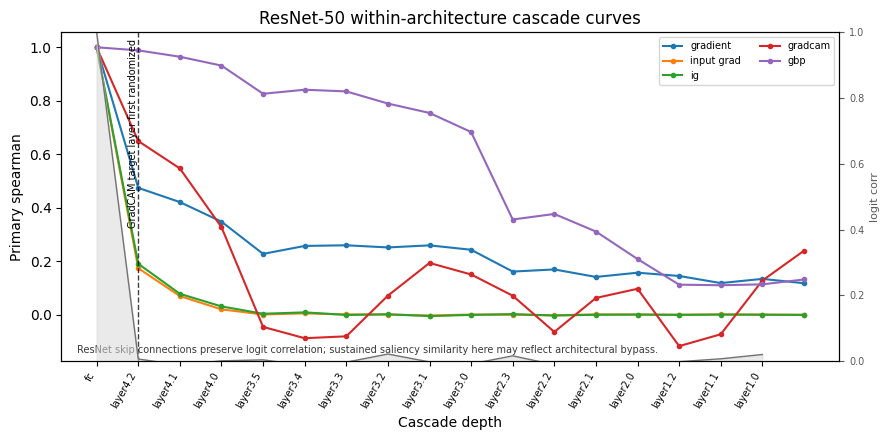

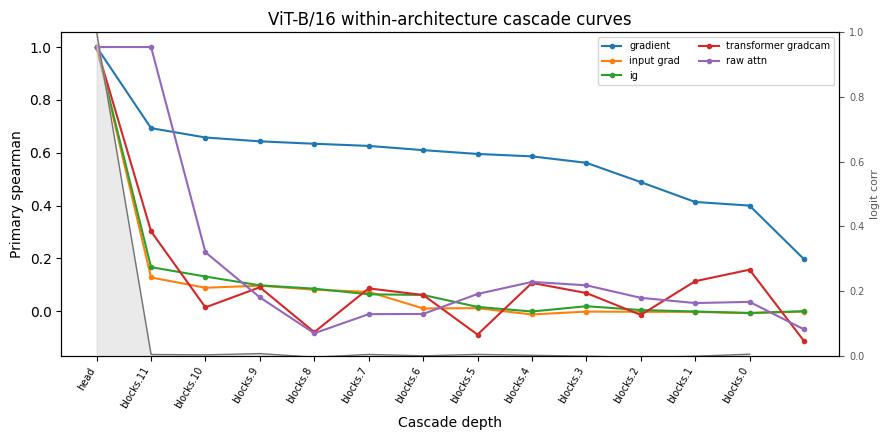

In [3]:

def plot_within_architecture_curves(metric="spearman"):
    for arch, cfg in ARCHS.items():
        order = _load_order(arch)
        fig, ax = plt.subplots(figsize=(9, 4.5))
        for method in cfg["methods"]:
            mean, std = _mean_std_curve(arch, method, metric=metric)
            if mean is None:
                continue
            x = np.arange(len(mean))
            _plot_curve_with_band(ax, x, mean, std, _method_label(method))
        x_depths = np.arange(len(order))
        _apply_arch_overlays(ax, arch, order, x_depths)
        if arch == "vit":
            add_gradcam_unreliable_overlay(ax, RESULTS_ROOT / arch, x_values=x_depths)
        ax.set_xlabel("Cascade depth")
        ax.set_ylabel("Primary %s" % metric)
        ax.set_title("%s within-architecture cascade curves" % cfg["title"])
        if order:
            ax.set_xticks(np.arange(len(order)))
            ax.set_xticklabels(order, rotation=60, ha="right", fontsize=7)
        ax.legend(fontsize=7, ncol=2)
        fig.tight_layout()
        out = FIGURES_DIR / ("within_arch_%s_%s.png" % (arch, metric))
        fig.savefig(out, dpi=150, bbox_inches="tight")
        plt.show()

plot_within_architecture_curves(metric="spearman")


In [4]:

def note_cross_architecture_guardrail():
    print(
        "Raw cross-architecture cascade curves are intentionally omitted. "
        "Use the sensitivity-ratio table below for cross-architecture summaries."
    )

note_cross_architecture_guardrail()


Raw cross-architecture cascade curves are intentionally omitted. Use the sensitivity-ratio table below for cross-architecture summaries.


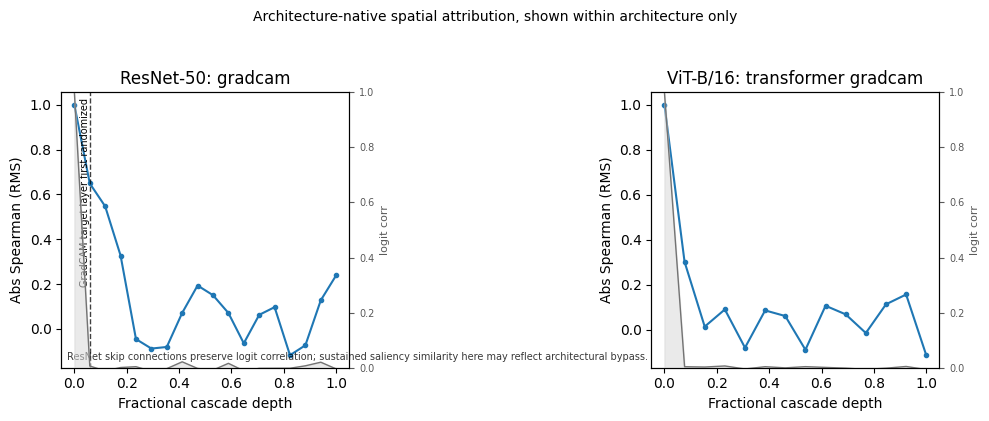

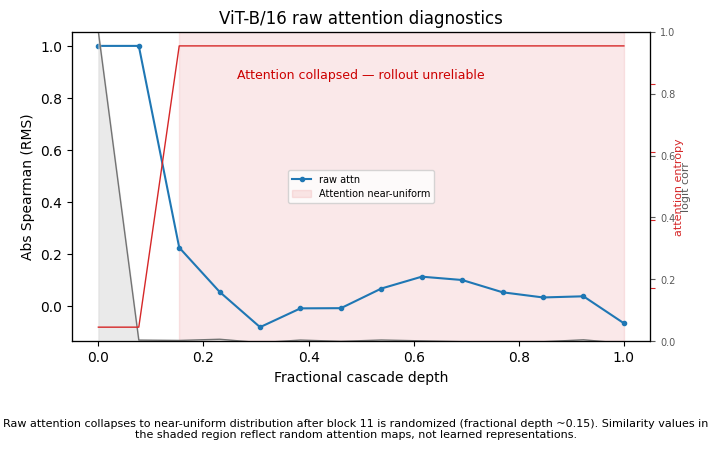

In [5]:

def plot_class_b_spatial_attribution():
    fig, axes = plt.subplots(1, len(CLASS_B_SPATIAL), figsize=(10, 4), sharey=False)
    if len(CLASS_B_SPATIAL) == 1:
        axes = [axes]
    for ax, arch in zip(axes, CLASS_B_SPATIAL):
        method = CLASS_B_SPATIAL[arch]
        mean, std = _mean_std_curve(arch, method, metric="spearman")
        order = _load_order(arch)
        if mean is None:
            ax.set_title("%s (missing)" % ARCHS[arch]["title"])
            continue
        x = _fraction_x(len(mean))
        _plot_curve_with_band(ax, x, mean, std, _method_label(method))
        _apply_arch_overlays(ax, arch, order, x)
        if arch == "vit":
            add_gradcam_unreliable_overlay(ax, RESULTS_ROOT / arch, x_values=x)
        ax.set_title("%s: %s" % (ARCHS[arch]["title"], _method_label(method)))
        ax.set_xlabel("Fractional cascade depth")
        ax.set_ylabel("Abs Spearman (RMS)")
    fig.suptitle(
        "Architecture-native spatial attribution, shown within architecture only",
        y=1.04,
        fontsize=10,
    )
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "class_b_spatial_attribution_within_arch.png", dpi=150, bbox_inches="tight")
    plt.show()


def plot_transformer_attention_diagnostics():
    arch = "vit"
    method = "raw_attn"
    mean, std = _mean_std_curve(arch, method, metric="spearman")
    if mean is None:
        print("Skip ViT attention diagnostics: raw_attn curves missing")
        return
    fig, ax = plt.subplots(figsize=(7, 4.5))
    x_values = _fraction_x(len(mean))
    _plot_curve_with_band(ax, x_values, mean, std, _method_label(method))
    add_logit_corr_band(ax, RESULTS_ROOT, arch, x_values=x_values)
    ax2 = add_attention_entropy_overlay(
        ax, RESULTS_ROOT / arch, num_patches=196, x_values=x_values
    )
    if ax2 is not None:
        ax2.set_ylabel("attention entropy", color="tab:red", fontsize=8, labelpad=10)
        ax2.set_yticklabels([])
        ax.text(
            0.5,
            0.85,
            "Attention collapsed — rollout unreliable",
            transform=ax.transAxes,
            fontsize=9,
            color="#cc0000",
            ha="center",
        )
    ax.set_title("%s raw attention diagnostics" % ARCHS[arch]["title"])
    ax.set_xlabel("Fractional cascade depth")
    ax.set_ylabel("Abs Spearman (RMS)")
    ax.legend(fontsize=7)
    fig.text(
        0.5,
        0.01,
        "Raw attention collapses to near-uniform distribution after block 11 is randomized "
        "(fractional depth ~0.15). Similarity values in the shaded region reflect random "
        "attention maps, not learned representations.",
        ha="center",
        va="bottom",
        fontsize=8,
        wrap=True,
    )
    fig.tight_layout(rect=(0, 0.10, 1, 1))
    fig.savefig(FIGURES_DIR / "attention_diagnostics_vit.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_class_b_spatial_attribution()
plot_transformer_attention_diagnostics()


In [6]:

def _load_curve_stats(arch, method):
    stats = []
    for d in _method_dirs(arch, method):
        p = d / ("%s_curve_stats.json" % method)
        if p.exists():
            with open(p) as f:
                stats.append(json.load(f))
    return stats


def _fmt_mean_std(values, precision=3):
    vals = np.array([v for v in values if v is not None and np.isfinite(v)], dtype=float)
    if vals.size == 0:
        return "--"
    if vals.size == 1:
        return ("%%.%df" % precision) % vals[0]
    return (("%%.%df $\\pm$ %%.%df") % (precision, precision)) % (np.mean(vals), np.std(vals))


def _sensitivity_methods_for_arch(arch):
    for method in CLASS_A_METHODS:
        yield "A", method
    for method in CLASS_B_METHODS[arch]:
        yield "B", method


def _load_logit_corr_for_arch(arch):
    tag = {"resnet50": "resnet", "vit": "vit"}.get(arch, arch)
    path = RESULTS_ROOT / "mechanistic" / ("logit_corr_%s.npy" % tag)
    if not path.exists():
        return None
    return np.load(path)


def build_sensitivity_ratio_table():
    rows = []
    for arch in ARCHS:
        logit_corr = _load_logit_corr_for_arch(arch)
        d_arch_auc = compute_d_arch_auc(logit_corr) if logit_corr is not None else np.nan
        for method_class, method in _sensitivity_methods_for_arch(arch):
            stats = _load_curve_stats(arch, method)
            if not stats:
                continue
            normalized_aucs = [s.get("normalized_auc") for s in stats]
            ratios = [
                compute_sensitivity_ratio(normalized_auc, logit_corr)
                if normalized_auc is not None and logit_corr is not None
                else np.nan
                for normalized_auc in normalized_aucs
            ]
            finite_ratios = [r for r in ratios if r is not None and np.isfinite(r)]
            ratio_mean = np.nanmean(finite_ratios) if finite_ratios else np.nan
            flag = ""
            if np.isfinite(ratio_mean) and ratio_mean > 1.5:
                flag = "potential failure"
            elif np.isfinite(ratio_mean) and ratio_mean < 0.5:
                flag = "potentially noise-driven"
            rows.append({
                "Architecture": ARCHS[arch]["title"],
                "Method Class": method_class,
                "Method": method,
                "D_half": _fmt_mean_std([s.get("d_half") for s in stats]),
                "D_arch": _fmt_mean_std([d_arch_auc]),
                "sensitivity_ratio": _fmt_mean_std(ratios),
                "final_sim": _fmt_mean_std([s.get("final_sim") for s in stats]),
                "normalized_auc": _fmt_mean_std(normalized_aucs),
                "Flag": flag,
            })
    return rows


def print_latex_table(rows):
    if not rows:
        print("No curve_stats JSON files found yet.")
        return
    cols = ["Architecture", "Method Class", "Method", "D_half", "D_arch", "sensitivity_ratio", "final_sim", "normalized_auc", "Flag"]
    line_end = r" \\"
    print(r"\begin{tabular}{lllllllll}")
    print(" & ".join(cols) + line_end)
    print(r"\hline")
    for row in rows:
        print(" & ".join(str(row[c]) for c in cols) + line_end)
    print(r"\end{tabular}")

sensitivity_rows = build_sensitivity_ratio_table()
print_latex_table(sensitivity_rows)


\begin{tabular}{lllllllll}
Architecture & Method Class & Method & D_half & D_arch & sensitivity_ratio & final_sim & normalized_auc & Flag \\
\hline
ResNet-50 & A & gradient & 0.056 & 0.034 & 0.772 & 0.126 & 0.254 &  \\
ResNet-50 & A & input_grad & 0.036 & 0.034 & 0.988 & -0.000 & 0.045 &  \\
ResNet-50 & A & ig & 0.036 & 0.034 & 0.986 & -0.000 & 0.047 &  \\
ResNet-50 & B & gradcam & 0.130 & 0.034 & 0.886 & 0.183 & 0.144 &  \\
ViT-B/16 & A & gradient & 0.757 & 0.040 & 0.440 & 0.299 & 0.578 & potentially noise-driven \\
ViT-B/16 & A & input_grad & 0.044 & 0.040 & 0.965 & -0.004 & 0.074 &  \\
ViT-B/16 & A & ig & 0.046 & 0.040 & 0.951 & -0.003 & 0.088 &  \\
ViT-B/16 & B & transformer_gradcam & 0.055 & 0.040 & 0.941 & 0.022 & 0.097 &  \\
\end{tabular}


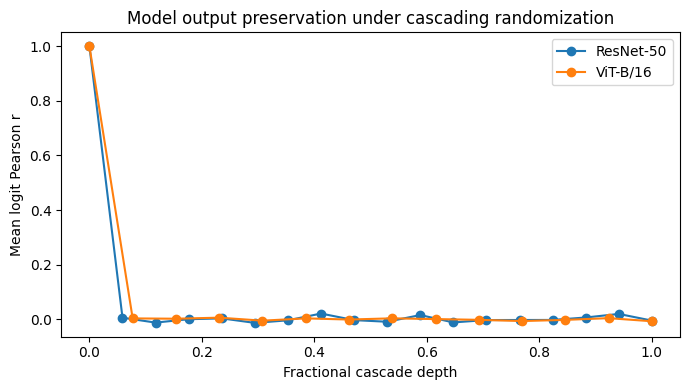

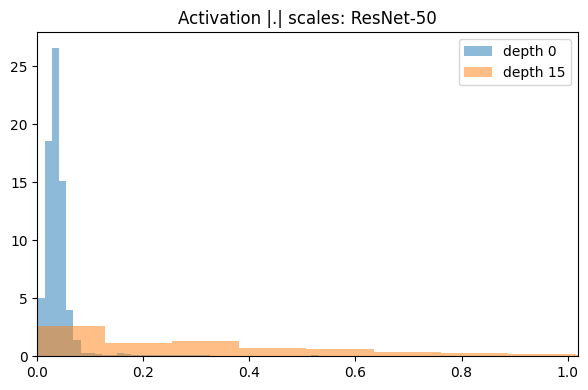

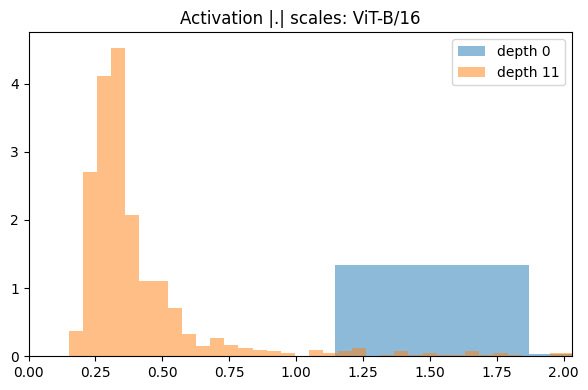

In [7]:

mech = RESULTS_ROOT / "mechanistic"
if any((mech / ("logit_corr_%s.npy" % tag)).exists() for tag, _ in MECH_ARCH_TAGS):
    fig, ax = plt.subplots(figsize=(7, 4))
    for tag, label in MECH_ARCH_TAGS:
        p = mech / ("logit_corr_%s.npy" % tag)
        if p.exists():
            vals = np.load(p)
            ax.plot(_fraction_x(len(vals)), vals, marker="o", label=label)
    ax.set_xlabel("Fractional cascade depth")
    ax.set_ylabel("Mean logit Pearson r")
    ax.set_title("Model output preservation under cascading randomization")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "logit_correlation.png", dpi=150)
    plt.show()

for tag, label in MECH_ARCH_TAGS:
    files = sorted(mech.glob("activation_scale_%s_depth*.npy" % tag))
    if len(files) < 2:
        continue
    a0, a1 = np.load(files[0]).ravel(), np.load(files[-1]).ravel()
    combined = np.concatenate([a0, a1])
    combined = combined[np.isfinite(combined)]
    x_max = float(np.percentile(combined, 99)) if combined.size else np.nan
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(a0, bins=50, alpha=0.5, density=True, label="depth 0")
    ax.hist(a1, bins=50, alpha=0.5, density=True, label="depth %d" % (len(files) - 1))
    if np.isfinite(x_max) and x_max > 0:
        ax.set_xlim(0, x_max)
    ax.set_title("Activation |.| scales: %s" % label)
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / ("activation_scales_%s.png" % tag), dpi=150)
    plt.show()


resnet50 occlusion gradient AUC: n=500 images, mean=0.775
resnet50 patch score spread: min=0.0084, max=0.1755, std=0.0354
resnet50 top 5 patch scores: [0.15118956 0.15319799 0.15934035 0.16133072 0.17552565]
vit occlusion gradient AUC: n=500 images, mean=0.716
vit patch score spread: min=0.0022, max=0.0941, std=0.0120
vit top 5 patch scores: [0.04751966 0.04921165 0.05208373 0.0694397  0.0940559 ]


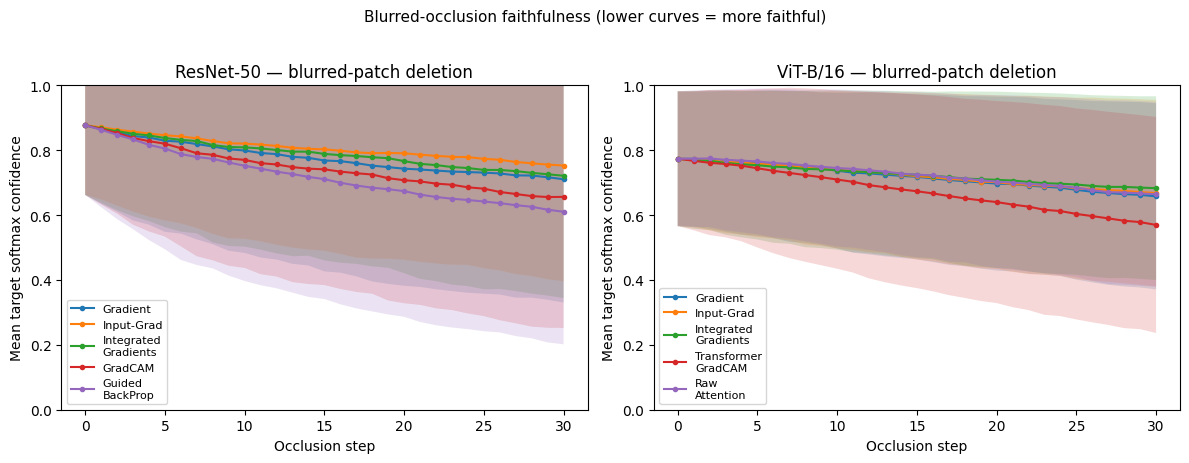

Saved /Users/alexatran/saliency_and_attention/results/figures/occlusion_faithfulness_curves.png


In [8]:

def _print_occlusion_diagnostics():
    for arch in ["resnet50", "vit"]:
        auc_path = RESULTS_ROOT / arch / "occlusion_gradient_auc.npy"
        if not auc_path.exists():
            print(f"{arch} occlusion_gradient_auc.npy NOT FOUND")
            continue
        auc = np.load(auc_path)
        print(
            f"{arch} occlusion gradient AUC: n={len(auc)} images, "
            f"mean={auc.mean():.3f}"
        )
        if len(auc) == 4:
            print(
                f"{arch}: reading smoke-test occlusion results; rerun with "
                "--num-images 500 --force-recompute before interpreting bars."
            )
        if len(auc) == 500:
            try:
                raw_map = load_arch_baseline_maps(
                    RESULTS_ROOT, arch, "gradient", norm="raw"
                )[0]
            except FileNotFoundError:
                print(f"{arch} baseline_gradient.npz NOT FOUND")
                continue
            scores = []
            for py in range(0, 224, 15):
                for px in range(0, 224, 15):
                    patch = raw_map[py:py+15, px:px+15]
                    scores.append(np.abs(patch).mean())
            scores = np.array(scores)
            print(
                f"{arch} patch score spread: min={scores.min():.4f}, "
                f"max={scores.max():.4f}, std={scores.std():.4f}"
            )
            print(f"{arch} top 5 patch scores: {np.sort(scores)[-5:]}")


def plot_occlusion_faithfulness():
    _print_occlusion_diagnostics()
    mech_tags = {"resnet50": "resnet", "vit": "vit"}
    out = plot_occlusion_faithfulness_curves(
        RESULTS_ROOT,
        ARCHS,
        FIGURES_DIR,
        mech_arch_tags=mech_tags,
        dpi=150,
        show=True,
    )
    if out is not None:
        print("Saved", out)


plot_occlusion_faithfulness()


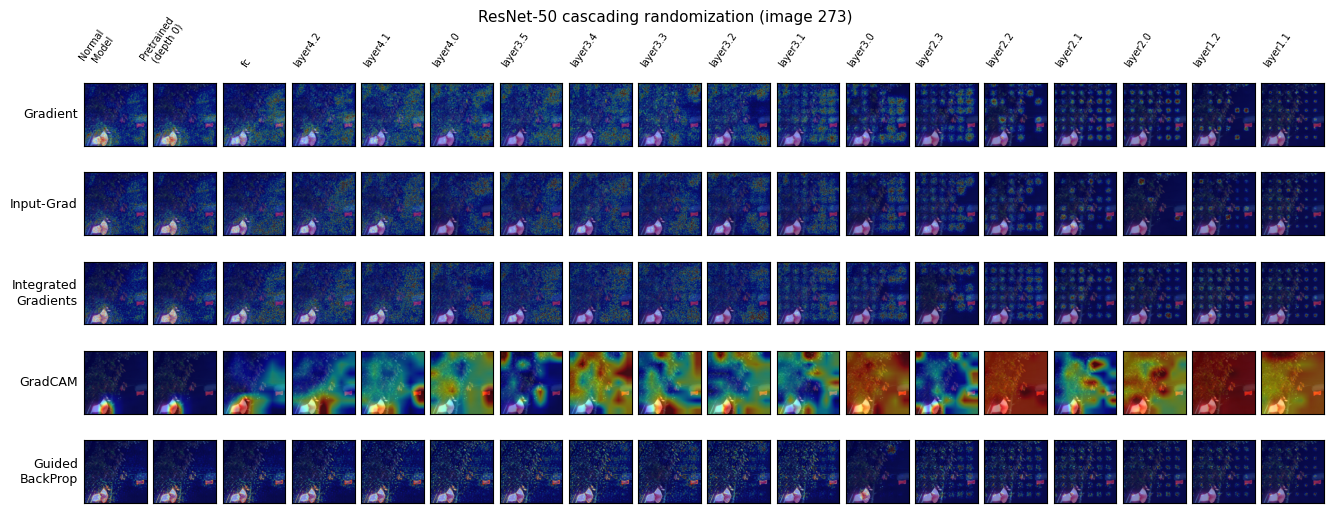

resnet50 image 273 -> cascade_grid_resnet50.png (jet overlay), cascade_grid_resnet50_masks.png
  extras: cascade_grid_resnet50_bwr_pct.png, cascade_grid_resnet50_jet_pct.png, cascade_grid_resnet50_turbo_pct.png, cascade_grid_resnet50_hot_pct.png, cascade_grid_resnet50_bwr_absmax.png


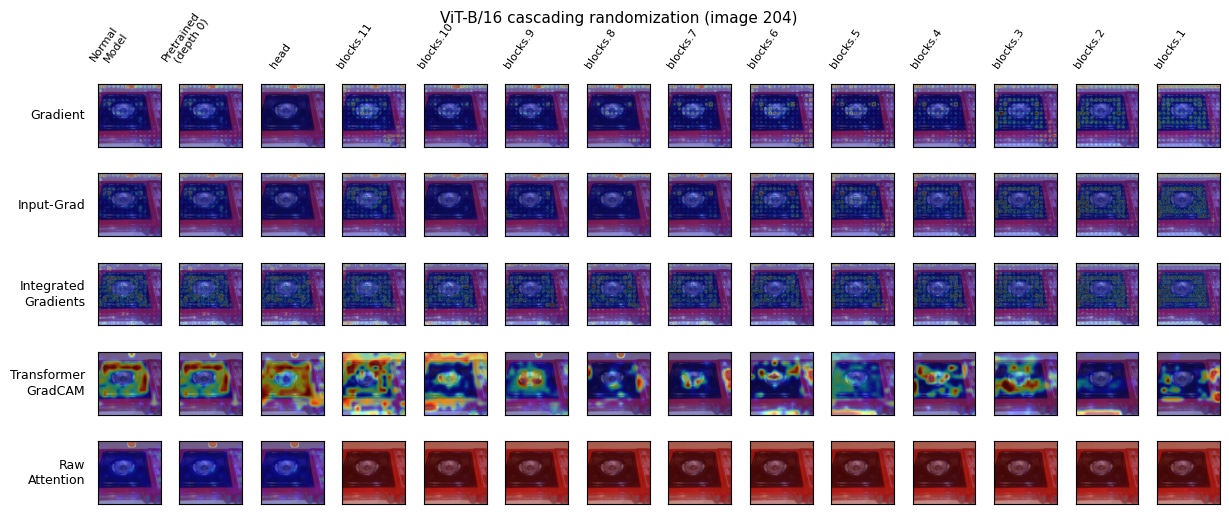

vit image 204 -> cascade_grid_vit.png (jet overlay), cascade_grid_vit_masks.png
  extras: cascade_grid_vit_bwr_pct.png, cascade_grid_vit_jet_pct.png, cascade_grid_vit_turbo_pct.png, cascade_grid_vit_hot_pct.png, cascade_grid_vit_bwr_absmax.png
Figures saved to /Users/alexatran/saliency_and_attention/results/figures


In [9]:

for arch, cfg in ARCHS.items():
    qual_path = RESULTS_ROOT / arch / "qual_bundle.npz"
    if not qual_path.exists():
        print("Skip %s: no qual_bundle.npz (run qual-only Modal job or pipeline with skip_qual=False)" % arch)
        continue
    data = np.load(qual_path, allow_pickle=True)
    img_idx = int(data["image_index"]) if "image_index" in data.files else 0
    order = list(data["order"])
    methods = [m for m in cfg["methods"] if ("baseline_" + m) in data.files]
    depth_indices = select_depth_indices(len(order), max_cols=None)
    base_title = cfg["title"] + " cascading randomization (image %d)" % img_idx

    # Primary (last-commit style): jet heatmap blended on the input image.
    plot_cascade_paper_grid(
        qual_path,
        methods,
        depth_indices=depth_indices,
        out_path=FIGURES_DIR / ("cascade_grid_%s.png" % arch),
        title=base_title,
        arch=arch,
        overlay=True,
        heatmap_cmap="jet",
        max_depth_cols=None,
        show=True,
    )
    # Secondary: grayscale masks (overlay=False).
    plot_cascade_paper_grid(
        qual_path,
        methods,
        depth_indices=depth_indices,
        out_path=FIGURES_DIR / ("cascade_grid_%s_masks.png" % arch),
        title=base_title + " [masks]",
        arch=arch,
        overlay=False,
        mask_cmap="gray",
        display_norm="minmax",
        max_depth_cols=None,
        show=False,
    )
    # Optional extra modes (percentile / turbo / bwr, etc.).
    saved_extra = []
    for suffix, preset in CASCADE_DISPLAY_PRESETS.items():
        if suffix == "overlay_jet":
            continue
        out = FIGURES_DIR / ("cascade_grid_%s_%s.png" % (arch, suffix))
        plot_cascade_paper_grid(
            qual_path,
            methods,
            depth_indices=depth_indices,
            out_path=out,
            title=base_title + " [%s]" % suffix,
            arch=arch,
            max_depth_cols=None,
            show=False,
            **preset,
        )
        saved_extra.append(out.name)
    print(
        "%s image %d -> cascade_grid_%s.png (jet overlay), cascade_grid_%s_masks.png"
        % (arch, img_idx, arch, arch)
    )
    if saved_extra:
        print("  extras:", ", ".join(saved_extra))

# Optional per-method vertical strips for slides
for arch, method, title in [
    ("resnet50", "gbp", "ResNet-50 GBP"),
    ("resnet50", "input_grad", "ResNet-50 Input-Grad"),
    ("resnet50", "ig", "ResNet-50 IG"),
    ("vit", "ig", "ViT IG"),
    ("vit", "transformer_gradcam", "ViT Transformer GradCAM"),
    ("vit", "raw_attn", "ViT raw attention"),
]:
    plot_cascading_grid(
        RESULTS_ROOT / arch / "qual_bundle.npz",
        method,
        out_path=FIGURES_DIR / ("cascade_%s_%s.png" % (arch, method)),
        title=title,
        arch=arch,
        overlay=True,
        show=False,
    )

print("Figures saved to", FIGURES_DIR)


In [10]:
import json
import random

manifest_path = RESULTS_ROOT / "diagnostics" / "subset_manifest_first500.json"
if not manifest_path.exists():
    raise FileNotFoundError(
        "Missing %s — run from repo root or re-download results." % manifest_path
    )
manifest = json.loads(manifest_path.read_text())

# Pick a random qual index (must be < num_images passed to Modal qual-only).
QUAL_NUM_IMAGES = 500
qual_image_index = random.randint(0, QUAL_NUM_IMAGES - 1)
print("Random qual image_index:", qual_image_index)
print(manifest[qual_image_index]["filename"], "—", manifest[qual_image_index]["class_name"])

# Browse by class name (optional)
for row in manifest:
    if "retriever" in row["class_name"].lower():
        print(row["dataset_index"], row["filename"], row["class_name"])

Random qual image_index: 465
ILSVRC2012_val_00017839.JPEG — ostrich
